In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

**Importing Dataset**

In [ ]:
df = pd.read_csv("/content/Dataset.csv")
df

df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

**Data preprocessing**

In [ ]:
df.isna().sum()

,0
Hour,0
HR,153399
O2Sat,202736
Temp,1026984
SBP,226265
MAP,193270
DBP,486554
Resp,238335
EtCO2,1494574
BaseExcess,1468065


In [ ]:
df = df.fillna(df.mean(numeric_only= True))
df


,Hour,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,...,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,Patient_ID
0,0,84.581443,97.193955,36.977228,123.750465,82.4001,63.830556,18.726498,32.957657,-0.689919,...,287.385706,196.013911,68.54,0,0.496571,0.503429,-0.02,1,0,17072
1,1,65.000000,100.000000,36.977228,123.750465,72.0000,63.830556,16.500000,32.957657,-0.689919,...,287.385706,196.013911,68.54,0,0.496571,0.503429,-0.02,2,0,17072
2,2,78.000000,100.000000,36.977228,123.750465,42.5000,63.830556,18.726498,32.957657,-0.689919,...,287.385706,196.013911,68.54,0,0.496571,0.503429,-0.02,3,0,17072
3,3,73.000000,100.000000,36.977228,123.750465,82.4001,63.830556,17.000000,32.957657,-0.689919,...,287.385706,196.013911,68.54,0,0.496571,0.503429,-0.02,4,0,17072
4,4,70.000000,100.000000,36.977228,129.000000,74.0000,69.000000,14.000000,32.957657,-0.689919,...,287.385706,330.000000,68.54,0,0.496571,0.503429,-0.02,5,0,17072
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1552205,21,83.000000,99.000000,36.977228,121.000000,77.0000,54.000000,22.000000,32.957657,-0.689919,...,287.385706,196.013911,88.00,0,1.000000,0.000000,-2.93,22,0,113911
1552206,22,80.000000,92.000000,36.977228,102.000000,73.0000,51.000000,24.000000,32.957657,-0.689919,...,287.385706,196.013911,88.00,0,1.000000,0.000000,-2.93,23,0,113911
1552207,23,95.000000,97.000000,36.700000,128.500000,83.0000,58.500000,25.000000,32.957657,-0.689919,...,287.385706,196.013911,88.00,0,1.000000,0.000000,-2.93,24,0,113911
1552208,24,104.000000,99.000000,36.977228,127.000000,85.0000,59.000000,24.000000,32.957657,-0.689919,...,287.385706,196.013911,88.00,0,1.000000,0.000000,-2.93,25,0,113911


In [ ]:
df['SepsisLabel'].value_counts()

,count
SepsisLabel,
0,1524294
1,27916


In [ ]:
df_agg = df.groupby('Patient_ID').agg({
    'SepsisLabel': 'max'
}).reset_index()
df_agg

,Patient_ID,SepsisLabel
0,1,0
1,2,0
2,3,0
3,4,0
4,5,0
...,...,...
40331,119996,0
40332,119997,0
40333,119998,0
40334,119999,0


In [ ]:
features = df.groupby('Patient_ID').mean().reset_index()
features = features.drop(columns=['SepsisLabel'])
df['SepsisLabel'] = (df['SepsisLabel'] > 0).astype(int)

In [ ]:
target = df.groupby('Patient_ID')['SepsisLabel'].max().reset_index()
target

,Patient_ID,SepsisLabel
0,1,0
1,2,0
2,3,0
3,4,0
4,5,0
...,...,...
40331,119996,0
40332,119997,0
40333,119998,0
40334,119999,0


In [ ]:
df_agg = features.merge(target, on='Patient_ID')
df_agg

,Patient_ID,Hour,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,...,WBC,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel
0,1,26.5,99.998282,92.535918,36.940334,126.129733,86.181504,63.830556,24.368629,32.957657,...,11.400242,287.385706,200.883766,83.14,0.0,0.496571,0.503429,-0.03,27.5,0
1,2,11.0,61.981802,97.008433,36.765343,132.130597,67.386961,50.941063,15.017652,32.957657,...,11.426996,287.385706,194.361132,75.91,0.0,0.000000,1.000000,-98.60,12.0,0
2,3,23.5,79.921757,95.578663,37.187944,139.015654,81.132506,55.572569,25.201656,32.957657,...,11.293505,287.385706,213.742208,45.82,0.0,1.000000,0.000000,-1195.71,24.5,0
3,4,14.0,101.212513,98.134066,36.869181,114.129358,68.725183,57.843391,18.868258,32.957657,...,11.313770,287.385706,195.047434,65.71,0.0,0.000000,1.000000,-8.77,15.0,0
4,5,23.5,79.249055,97.327849,36.980040,128.260649,84.060481,63.830556,17.752405,32.957657,...,11.164338,287.385706,201.200541,28.09,1.0,1.000000,0.000000,-0.05,25.5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40331,119996,23.5,89.253393,98.049748,36.856972,130.890654,84.418758,71.416493,19.045229,32.957657,...,11.470438,287.385706,196.888621,84.00,0.0,0.496571,0.503429,-6.69,24.5,0
40332,119997,12.0,62.003258,96.847758,36.955961,119.730019,90.596004,69.993222,19.588719,33.439350,...,11.362693,287.385706,195.452798,30.00,1.0,0.496571,0.503429,-0.02,13.0,0
40333,119998,24.0,80.827961,96.370688,36.917499,149.943982,108.579614,83.074206,20.163091,32.957657,...,11.496625,287.385706,196.094692,60.00,0.0,1.000000,0.000000,-53.64,25.0,0
40334,119999,9.5,93.358144,93.169395,37.137921,139.925047,98.990010,73.358056,21.372650,32.957657,...,11.371765,287.385706,202.762520,84.00,0.0,1.000000,0.000000,-10.74,10.5,0


In [ ]:
print("Unique SepsisLabel values:", df_agg['SepsisLabel'].unique())
print(df_agg['SepsisLabel'].value_counts())

Unique SepsisLabel values: [0 1]
SepsisLabel
0    37404
1     2932
Name: count, dtype: int64


**Split Features And Targets**

In [ ]:
X = df_agg.drop(['SepsisLabel', 'Patient_ID'], axis=1)
y = df_agg['SepsisLabel']
df_agg


,Patient_ID,Hour,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,...,WBC,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel
0,1,26.5,99.998282,92.535918,36.940334,126.129733,86.181504,63.830556,24.368629,32.957657,...,11.400242,287.385706,200.883766,83.14,0.0,0.496571,0.503429,-0.03,27.5,0
1,2,11.0,61.981802,97.008433,36.765343,132.130597,67.386961,50.941063,15.017652,32.957657,...,11.426996,287.385706,194.361132,75.91,0.0,0.000000,1.000000,-98.60,12.0,0
2,3,23.5,79.921757,95.578663,37.187944,139.015654,81.132506,55.572569,25.201656,32.957657,...,11.293505,287.385706,213.742208,45.82,0.0,1.000000,0.000000,-1195.71,24.5,0
3,4,14.0,101.212513,98.134066,36.869181,114.129358,68.725183,57.843391,18.868258,32.957657,...,11.313770,287.385706,195.047434,65.71,0.0,0.000000,1.000000,-8.77,15.0,0
4,5,23.5,79.249055,97.327849,36.980040,128.260649,84.060481,63.830556,17.752405,32.957657,...,11.164338,287.385706,201.200541,28.09,1.0,1.000000,0.000000,-0.05,25.5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40331,119996,23.5,89.253393,98.049748,36.856972,130.890654,84.418758,71.416493,19.045229,32.957657,...,11.470438,287.385706,196.888621,84.00,0.0,0.496571,0.503429,-6.69,24.5,0
40332,119997,12.0,62.003258,96.847758,36.955961,119.730019,90.596004,69.993222,19.588719,33.439350,...,11.362693,287.385706,195.452798,30.00,1.0,0.496571,0.503429,-0.02,13.0,0
40333,119998,24.0,80.827961,96.370688,36.917499,149.943982,108.579614,83.074206,20.163091,32.957657,...,11.496625,287.385706,196.094692,60.00,0.0,1.000000,0.000000,-53.64,25.0,0
40334,119999,9.5,93.358144,93.169395,37.137921,139.925047,98.990010,73.358056,21.372650,32.957657,...,11.371765,287.385706,202.762520,84.00,0.0,1.000000,0.000000,-10.74,10.5,0


In [ ]:
X = df_agg.drop(['SepsisLabel', 'Patient_ID'], axis=1)
y = df_agg['SepsisLabel']


In [ ]:
def feature_engineering(X):
    X = X.copy()

    # Example: difference features (very useful in medical data)
    for col in X.columns[:5]:  # adjust important columns
        X[f"{col}_diff"] = X[col].diff().fillna(0)

    # Rolling mean (trend capturing)
    for col in X.columns[:5]:
        X[f"{col}_rolling_mean"] = X[col].rolling(window=3).mean().fillna(method='bfill')

    # Fill missing values
    X = X.fillna(X.median())

    return X

X = feature_engineering(X)

/tmp/ipykernel_23588/3994826737.py:10: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X[f"{col}_rolling_mean"] = X[col].rolling(window=3).mean().fillna(method='bfill')
/tmp/ipykernel_23588/3994826737.py:10: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X[f"{col}_rolling_mean"] = X[col].rolling(window=3).mean().fillna(method='bfill')
/tmp/ipykernel_23588/3994826737.py:10: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X[f"{col}_rolling_mean"] = X[col].rolling(window=3).mean().fillna(method='bfill')
/tmp/ipykernel_23588/3994826737.py:10: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X[f"{col}_rolling_mean"] = X[col].rolling(window=3).mean()

**Train And Test**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
neg = np.sum(y_train == 0)
pos = np.sum(y_train == 1)

scale_pos_weight = neg / pos
print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 12.754475703324808


# **Logistic Regression**

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

print("\n🔹 Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(confusion_matrix(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))


🔹 Logistic Regression Results
Accuracy: 0.9339365394149727
[[7459   23]
 [ 510   76]]
              precision    recall  f1-score   support

           0       0.94      1.00      0.97      7482
           1       0.77      0.13      0.22       586

    accuracy                           0.93      8068
   macro avg       0.85      0.56      0.59      8068
weighted avg       0.92      0.93      0.91      8068



# **Random Forest**

In [ ]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("\n🌳 Random Forest Results")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))




🌳 Random Forest Results
Accuracy: 0.9571145265245414
[[7427   55]
 [ 291  295]]
              precision    recall  f1-score   support

           0       0.96      0.99      0.98      7482
           1       0.84      0.50      0.63       586

    accuracy                           0.96      8068
   macro avg       0.90      0.75      0.80      8068
weighted avg       0.95      0.96      0.95      8068



# **Gradient Booosting Model**

In [ ]:
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1)
gb_model.fit(X_train, y_train)

# Predict probabilities
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]

# Lower threshold from 0.5 → 0.3
threshold = 0.3
y_pred_gb = (y_prob_gb > threshold).astype(int)

pr_auc = auc(recalls, precisions)
print("PR-AUC:", pr_auc)

print("\n🚀 Gradient Boosting")
print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print(confusion_matrix(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))

PR-AUC: 0.7511958625457287

🚀 Gradient Boosting
Accuracy: 0.9600892414476946
[[7368  114]
 [ 208  378]]
              precision    recall  f1-score   support

           0       0.97      0.98      0.98      7482
           1       0.77      0.65      0.70       586

    accuracy                           0.96      8068
   macro avg       0.87      0.81      0.84      8068
weighted avg       0.96      0.96      0.96      8068



# **XG Boost Model**

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import precision_recall_curve, auc, confusion_matrix, classification_report

model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='aucpr',
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

param_grid = {
    "max_depth": [3, 4, 5],
    "min_child_weight": [5, 7, 10],
    "gamma": [1, 3],
    "subsample": [0.7, 0.8],
    "colsample_bytree": [0.7, 0.8],
    "reg_alpha": [0.5, 1],
    "reg_lambda": [5, 10],
    "n_estimators": [200, 300],
    "learning_rate": [0.05, 0.1]
}

search = RandomizedSearchCV(
    model,
    param_distributions=param_grid,
    n_iter=15,
    scoring='average_precision',
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

search.fit(X_train, y_train)

best_model = search.best_estimator_
print("Best Params:", search.best_params_)

y_probs = best_model.predict_proba(X_test)[:, 1]

# =========================
# 9. THRESHOLD TUNING (CRITICAL)
# =========================
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)

pr_auc = auc(recalls, precisions)
print("PR-AUC:", pr_auc)

# Best threshold using F1
f1_scores = (2 * precisions * recalls) / (precisions + recalls + 1e-6)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print("\nBest Threshold:", best_threshold)
print("Precision:", precisions[best_idx])
print("Recall:", recalls[best_idx])

# =========================
# 10. FINAL PREDICTIONS
# =========================
y_pred = (y_probs >= best_threshold).astype(int)

# =========================
# 11. FINAL EVALUATION
# =========================
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))
# xgb_model = XGBClassifier(
#     n_estimators=200,
#     learning_rate=0.05,
#     max_depth=4,
#     scale_pos_weight= len(y_train[y_train==0]) / len(y_train[y_train==1]),
#     random_state=42
# )

# xgb_model.fit(X_train, y_train)

# y_prob = xgb_model.predict_proba(X_test)[:,1]
# y_pred = (y_prob > 0.42).astype(int)

# print(confusion_matrix(y_test, y_pred))
# print(classification_report(y_test, y_pred))

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best Params: {'subsample': 0.8, 'reg_lambda': 10, 'reg_alpha': 0.5, 'n_estimators': 300, 'min_child_weight': 10, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 1, 'colsample_bytree': 0.8}
PR-AUC: 0.7480135134963621

Best Threshold: 0.74570733
Precision: 0.7486033519553073
Recall: 0.6860068259385665

Confusion Matrix:
[[7347  135]
 [ 184  402]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      7482
           1       0.75      0.69      0.72       586

    accuracy                           0.96      8068
   macro avg       0.86      0.83      0.85      8068
weighted avg       0.96      0.96      0.96      8068



**LightGBM MODEL**

In [ ]:
import lightgbm as lgb
lgb_model = lgb.LGBMClassifier(
    objective='binary',
    class_weight={0:1, 1:scale_pos_weight},  # important
    random_state=42
)

# =========================
# 4. HYPERPARAMETER TUNING
# =========================
param_grid = {
    'num_leaves': [20, 31, 50],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [200, 300, 400],
    'min_child_samples': [20, 30, 50],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'reg_alpha': [0, 0.5, 1],
    'reg_lambda': [1, 5, 10]
}

search = RandomizedSearchCV(
    lgb_model,
    param_distributions=param_grid,
    n_iter=15,
    scoring='average_precision',  # PR-AUC
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

search.fit(X_train, y_train)

best_lgb = search.best_estimator_

print("Best Params:", search.best_params_)

# =========================
# 5. PREDICT PROBABILITIES
# =========================
y_probs = best_lgb.predict_proba(X_test)[:, 1]

# =========================
# 6. PR-AUC
# =========================
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)

pr_auc = auc(recalls, precisions)
print("PR-AUC:", pr_auc)

# =========================
# 7. THRESHOLD TUNING
# =========================
f1_scores = (2 * precisions * recalls) / (precisions + recalls + 1e-6)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print("\nBest Threshold:", best_threshold)
print("Precision:", precisions[best_idx])
print("Recall:", recalls[best_idx])

# =========================
# 8. FINAL PREDICTION
# =========================
y_pred = (y_probs >= best_threshold).astype(int)

# =========================
# 9. EVALUATION
# =========================
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Fitting 3 folds for each of 15 candidates, totalling 45 fits
[LightGBM] [Info] Number of positive: 2346, number of negative: 29922
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.025567 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 12210
[LightGBM] [Info] Number of data points in the train set: 32268, number of used features: 51
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
Best Params: {'subsample': 0.9, 'reg_lambda': 1, 'reg_alpha': 0, 'num_leaves': 20, 'n_estimators': 300, 'min_child_samples': 20, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 0.9}
PR-AUC: 0.7511958625457287

Best Threshold: 0.7821602878328595
Precision: 0.7887323943661971
Recall: 0.6689419795221843

Confusion Matrix:
[[7377  105]
 [ 194  392]]

Classification Report:
              precision    recall  f1-score   support

       


🔹 Global Feature Importance (Summary Plot)


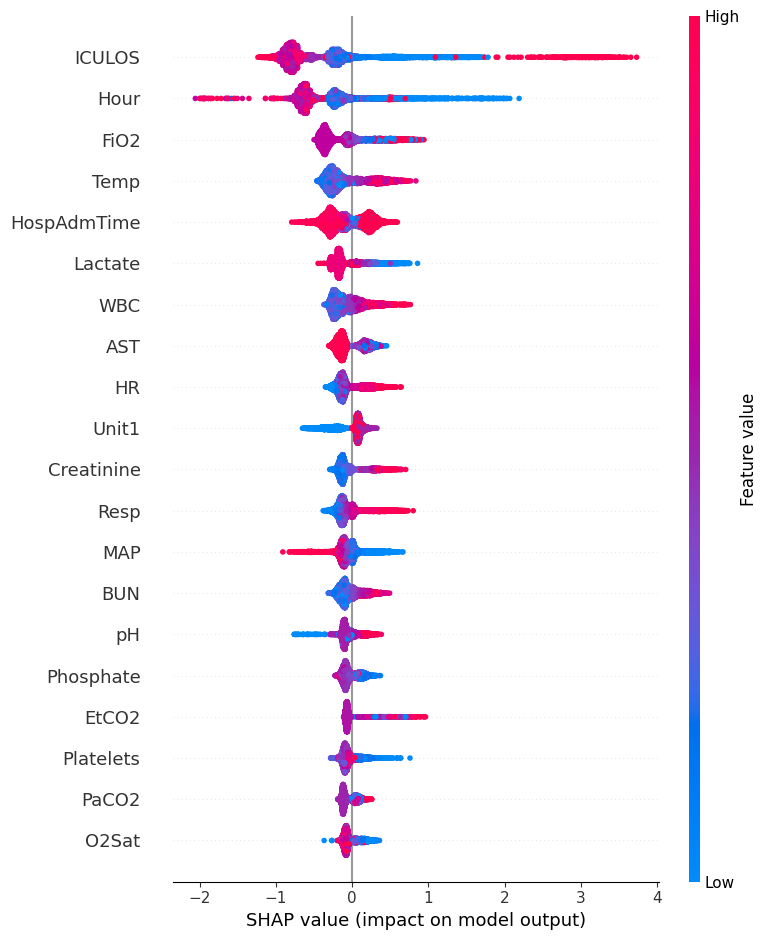


🔹 Top Important Features


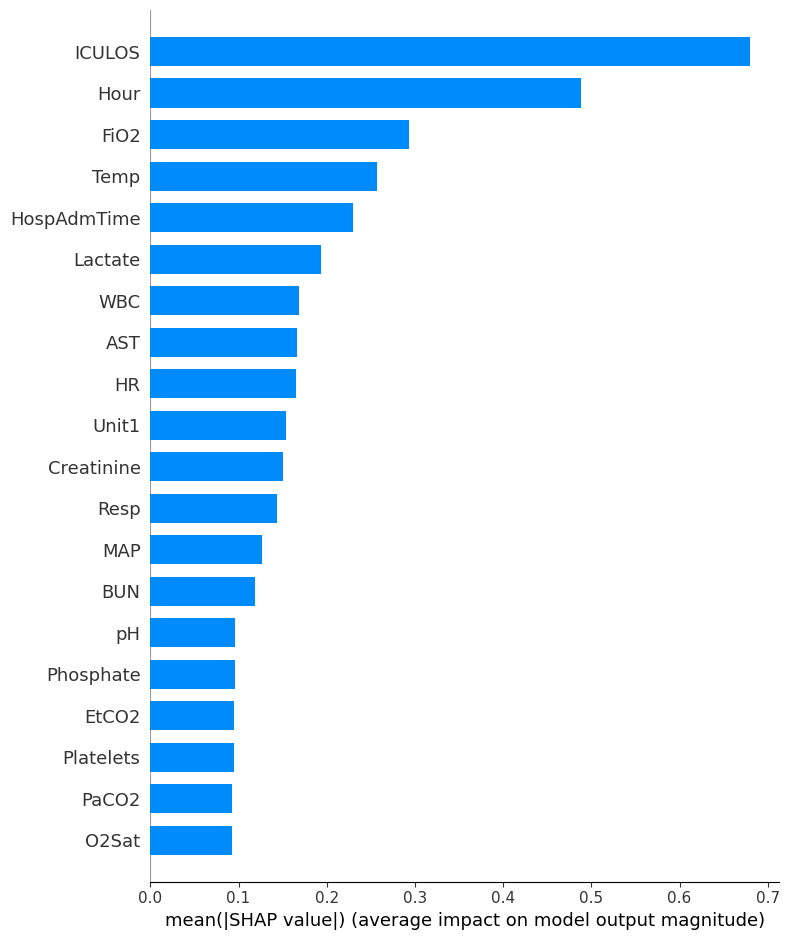


🔹 Explaining prediction for ONE patient


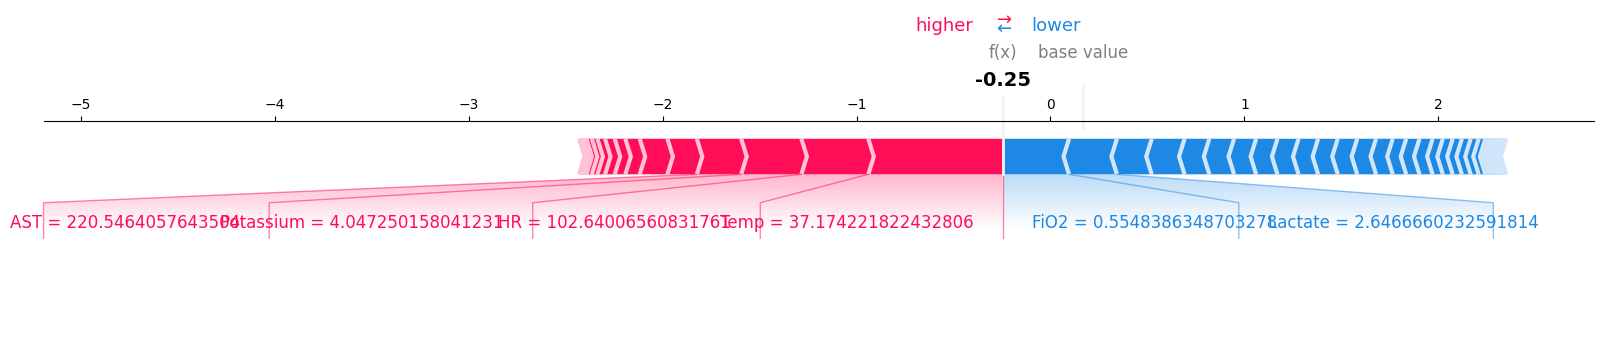


🔹 Waterfall Plot (Step-by-step contribution)


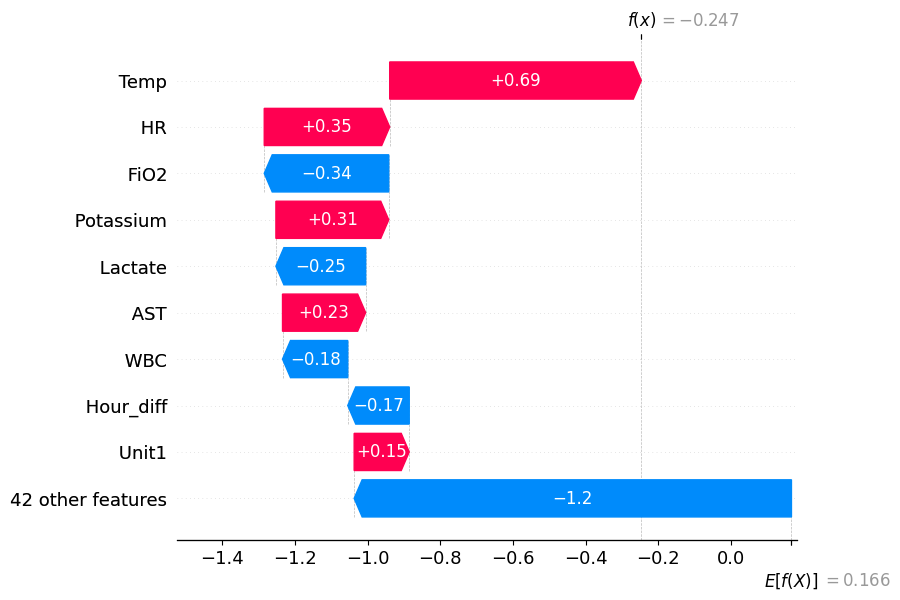

In [ ]:
# =========================
# 12. SHAP EXPLAINABILITY
# =========================

import shap
import matplotlib.pyplot as plt

# Initialize JS visualization (for notebooks like Colab)
shap.initjs()

# =========================
# 1. CREATE EXPLAINER
# =========================
explainer = shap.TreeExplainer(best_model)

# Compute SHAP values
shap_values = explainer.shap_values(X_test)

# =========================
# 2. GLOBAL FEATURE IMPORTANCE
# =========================
print("\n🔹 Global Feature Importance (Summary Plot)")
shap.summary_plot(shap_values, X_test)

# =========================
# 3. BAR PLOT (TOP FEATURES)
# =========================
print("\n🔹 Top Important Features")
shap.summary_plot(shap_values, X_test, plot_type="bar")

# =========================
# 4. SINGLE PREDICTION EXPLANATION
# =========================
# Choose one patient/sample
sample_index = 0

print("\n🔹 Explaining prediction for ONE patient")

shap.force_plot(
    explainer.expected_value,
    shap_values[sample_index],
    X_test.iloc[sample_index],
    matplotlib=True
)

# =========================
# 5. WATERFALL PLOT (BEST FOR VIVA)
# =========================
print("\n🔹 Waterfall Plot (Step-by-step contribution)")

shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value,
    shap_values[sample_index],
    X_test.iloc[sample_index]
)

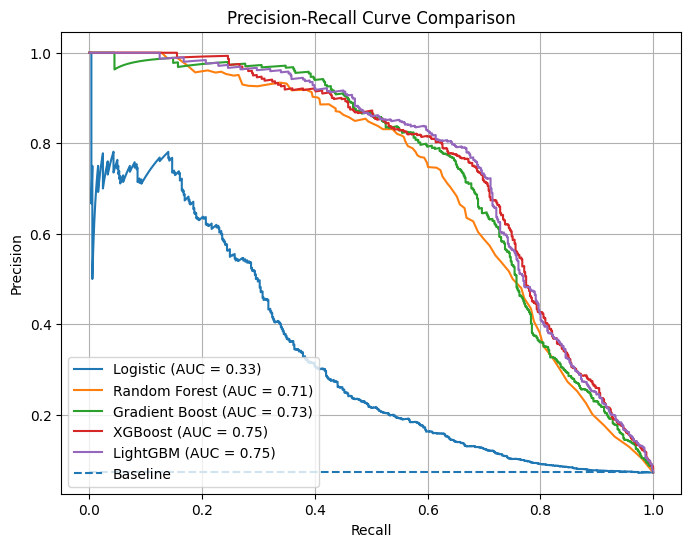

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve

# Get probabilities
y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]
y_prob_gb = gb_model.predict_proba(X_test)[:,1]
y_prob_rf = rf_model.predict_proba(X_test)[:,1]
y_prob_xgb = best_model.predict_proba(X_test)[:,1]
y_prob_lgb = best_lgb.predict_proba(X_test)[:, 1]

# Logistic
prec_log, rec_log, _ = precision_recall_curve(y_test, y_prob_log)
auc_log = auc(rec_log, prec_log)

# RF
prec_rf, rec_rf, _ = precision_recall_curve(y_test, y_prob_rf)
auc_rf = auc(rec_rf, prec_rf)

# GB
prec_gb, rec_gb, _ = precision_recall_curve(y_test, y_prob_gb)
auc_gb = auc(rec_gb, prec_gb)

# XGB
prec_xgb, rec_xgb, _ = precision_recall_curve(y_test, y_prob_xgb)
auc_xgb = auc(rec_xgb, prec_xgb)

# LGB
prec_lgb, rec_lgb, _ = precision_recall_curve(y_test, y_prob_lgb)
auc_lgb = auc(rec_lgb, prec_lgb)

# Plot
plt.figure(figsize=(8,6))

plt.plot(rec_log, prec_log, label=f"Logistic (AUC = {auc_log:.2f})")
plt.plot(rec_rf, prec_rf, label=f"Random Forest (AUC = {auc_rf:.2f})")
plt.plot(rec_gb, prec_gb, label=f"Gradient Boost (AUC = {auc_gb:.2f})")
plt.plot(rec_xgb, prec_xgb, label=f"XGBoost (AUC = {auc_xgb:.2f})")
plt.plot(rec_lgb, prec_lgb, label=f"LightGBM (AUC = {auc_lgb:.2f})")

# Baseline (IMPORTANT)
baseline = sum(y_test) / len(y_test)
plt.hlines(baseline, 0, 1, linestyles='dashed', label="Baseline")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.grid()

plt.show()